# MNIST CNN Model

This notebook trains a Convolutional Neural Network (CNN) on the MNIST handwritten digit dataset. The model learns patterns from thousands of digit images and predicts which number each image represents. After training, the model achieves very high accuracy on unseen test data. I also displayed some correct and incorrect predictions to understand how the model behaves.

In [3]:
import numpy as np
import keras
from keras import layers
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()
batch_size = 128
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])



x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 106ms/step - accuracy: 0.8880 - loss: 0.3631 - val_accuracy: 0.9745 - val_loss: 0.0903
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.9651 - loss: 0.1159 - val_accuracy: 0.9832 - val_loss: 0.0586
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - accuracy: 0.9739 - loss: 0.0857 - val_accuracy: 0.9868 - val_loss: 0.0459
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9779 - loss: 0.0715 - val_accuracy: 0.9865 - val_loss: 0.0490
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9808 - loss: 0.0614 - val_accuracy: 0.9878 - val_loss: 0.0398
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9822 - loss: 0.0572 - val_accuracy: 0.9892 - val_loss: 0.0369
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9839 - loss: 0.0522 - val_accuracy: 0.9920 - val_loss: 0.0344
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9847 - loss: 0.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


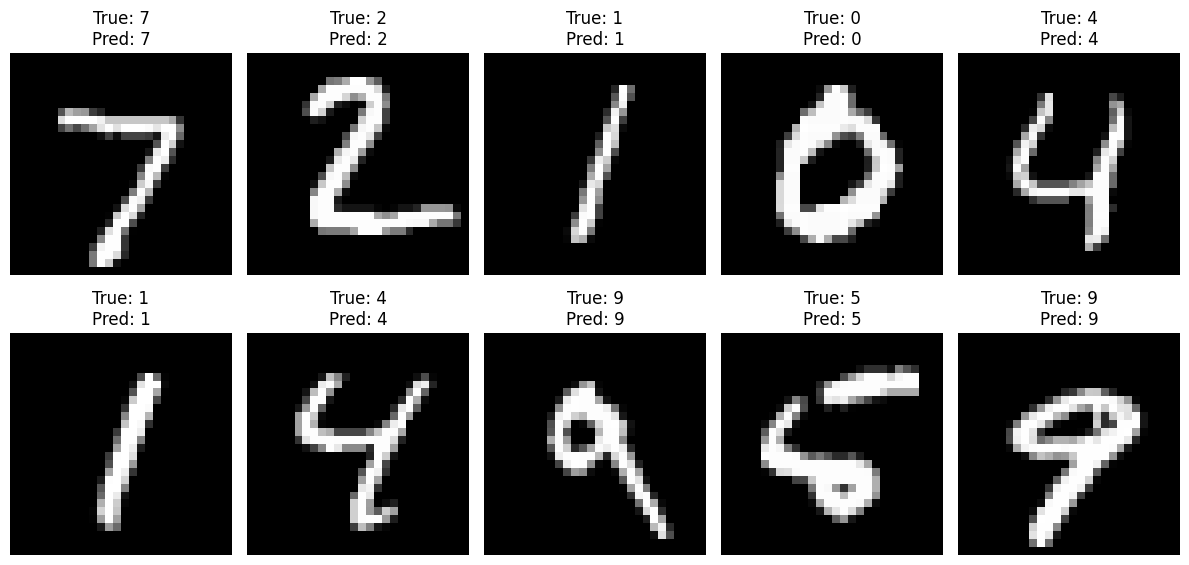

In [5]:
import numpy as np
import matplotlib.pyplot as plt
sample_images = x_test[:10]
sample_labels = np.argmax(y_test[:10], axis=1)

predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].squeeze(), cmap="gray")
    ax.set_title(f"True: {sample_labels[i]}\nPred: {predicted_labels[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


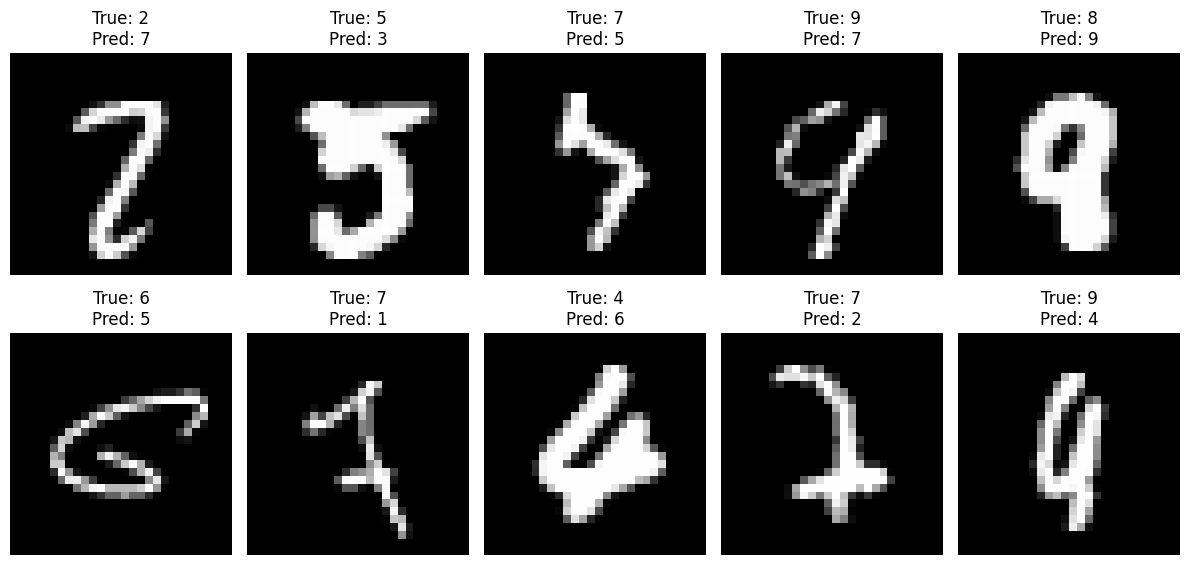

In [6]:
import numpy as np
import matplotlib.pyplot as plt

all_predictions = model.predict(x_test)
predicted_labels = np.argmax(all_predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)
wrong_indices = np.where(predicted_labels != true_labels)[0]
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    idx = wrong_indices[i]

    ax.imshow(x_test[idx].squeeze(), cmap="gray")
    ax.set_title(
        f"True: {true_labels[idx]}\nPred: {predicted_labels[idx]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()